# Quality Control and Preprocessing

Reproducing the QC pipeline from Bhat-Nakshatri et al. 2021 (Cell Reports Medicine) 
on the healthy breast scRNA-seq atlas (GEO: GSE164898). This notebook loads all 8 
donor samples, computes standard QC metrics, filters low-quality cells and doublets, 
and produces a combined, normalized AnnData object for downstream analysis.

In [4]:
import os
os.environ['NUMBA_NUM_THREADS'] = '64'  # cap thread usage 

import scanpy as sc
import numpy as np
import pandas as pd

sc.settings.verbosity = 1

## Load samples and compute QC metrics

Eight samples are loaded (individual donors D1–D5, D11, and two pooled cryopreserved 
sets D6–D10). For each cell we compute the number of detected genes, total UMI counts, 
and percentage of mitochondrial reads — standard metrics for identifying empty 
droplets, doublets, and dying cells.

In [29]:
import warnings
import scanpy as sc

adatas = {}

samples = {
    "D1": "GSM5022599_D1_filtered_feature_bc_matrix.h5",
    "D2": "GSM5022600_D2_filtered_feature_bc_matrix.h5",
    "D3": "GSM5022601_D3_filtered_feature_bc_matrix.h5",
    "D4": "GSM5022602_D4_filtered_feature_bc_matrix.h5",
    "D5": "GSM5022603_D5_filtered_feature_bc_matrix.h5",
    "D6-D10_CMG": "GSM5022604_D6-D10_Pool_CMG_filtered_feature_bc_matrix.h5",
    "D6-D10_HN": "GSM5022605_D6-D10_Pool_HN_filtered_feature_bc_matrix.h5",
    "D11": "GSM5022606_D11_filtered_feature_bc_matrix.h5",
}

for name, path in samples.items():

    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="Variable names are not unique.*",
            category=UserWarning,
            module="anndata"
        )
        ad = sc.read_10x_h5(path)

    ad.var_names_make_unique()
    ad.obs_names_make_unique()

    # Yeh missing tha — QC metrics compute karo
    ad.var['mt'] = ad.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(ad, qc_vars=['mt'], percent_top=None,
                                log1p=False, inplace=True)

    adatas[name] = ad
    print(f"{name}: {ad.n_obs} cells x {ad.n_vars} genes")

/home/bioinfo3/miniconda3/envs/Seurat/lib/python3.14/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


D1: 4853 cells x 33538 genes


/home/bioinfo3/miniconda3/envs/Seurat/lib/python3.14/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


D2: 1399 cells x 33538 genes


/home/bioinfo3/miniconda3/envs/Seurat/lib/python3.14/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


...

/home/bioinfo3/miniconda3/envs/Seurat/lib/python3.14/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


D6-D10_CMG: 10961 cells x 33538 genes


/home/bioinfo3/miniconda3/envs/Seurat/lib/python3.14/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


D6-D10_HN: 9651 cells x 33538 genes
D11: 8334 cells x 33538 genes


/home/bioinfo3/miniconda3/envs/Seurat/lib/python3.14/site-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


## QC visualization

Per-sample distributions of the three QC metrics are visualized to confirm that the 
chosen filtering thresholds appropriately separate high-quality cells from empty 
droplets, doublets, and dying cells.

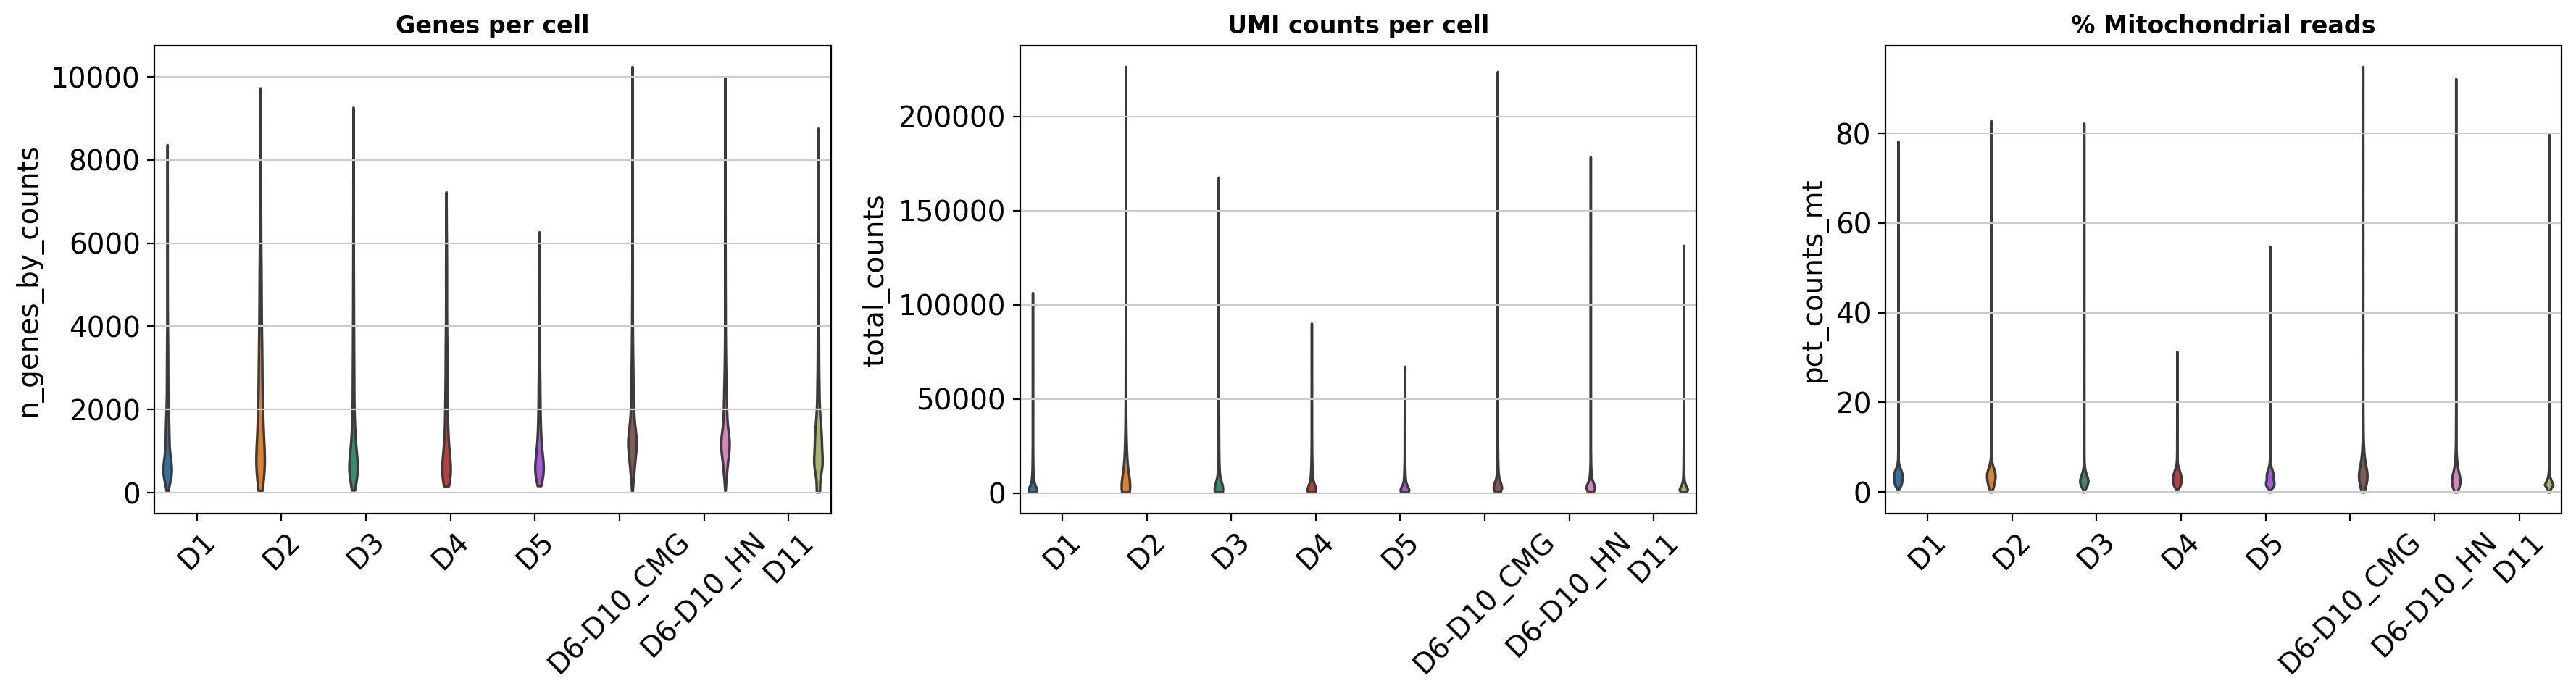

In [34]:
import matplotlib.pyplot as plt
import scanpy as sc

# fixes the warning at the source — no separate obs_names_make_unique() needed
adata_qc_check = sc.concat(
    adatas,
    label='sample',
    index_unique='-'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(
    axes,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    ['Genes per cell', 'UMI counts per cell', '% Mitochondrial reads']
):
    sc.pl.violin(
        adata_qc_check,
        metric,
        groupby='sample',
        rotation=45,
        stripplot=False,
        ax=ax,
        show=False,
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.subplots_adjust(wspace=0.4) 
plt.tight_layout()
plt.savefig('qc_violin_prefilter.png', dpi=300, bbox_inches='tight')
plt.show()

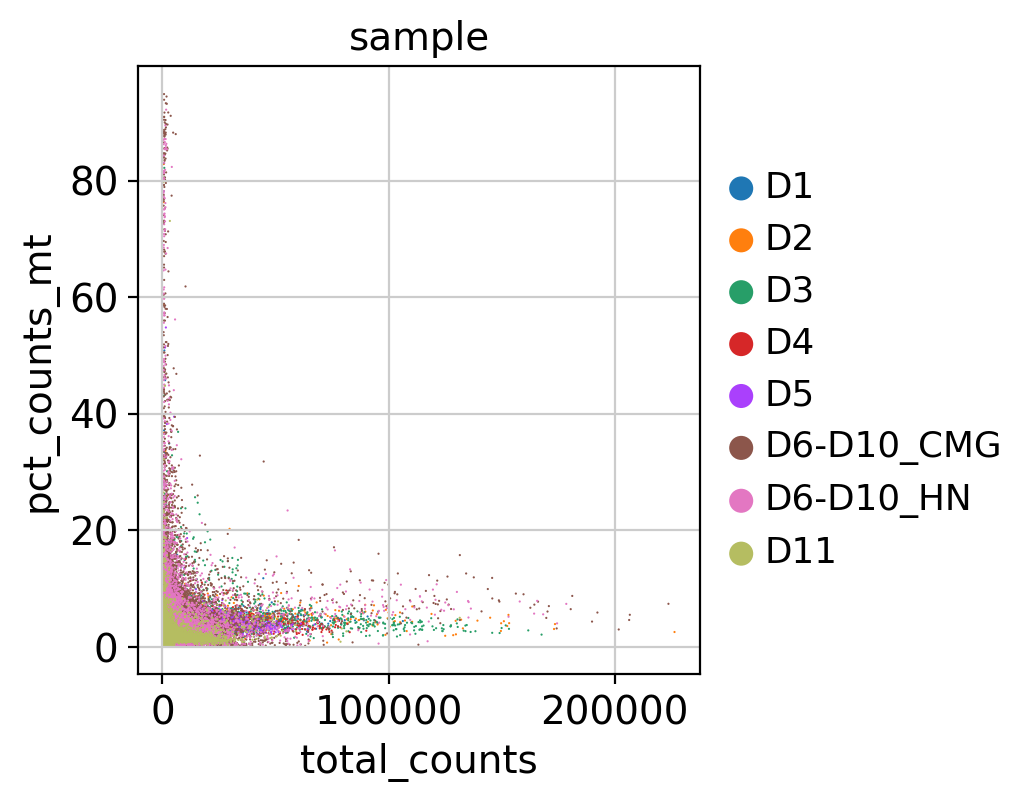

In [31]:
sc.pl.scatter(adata_qc_check, x='total_counts', y='pct_counts_mt', color='sample')

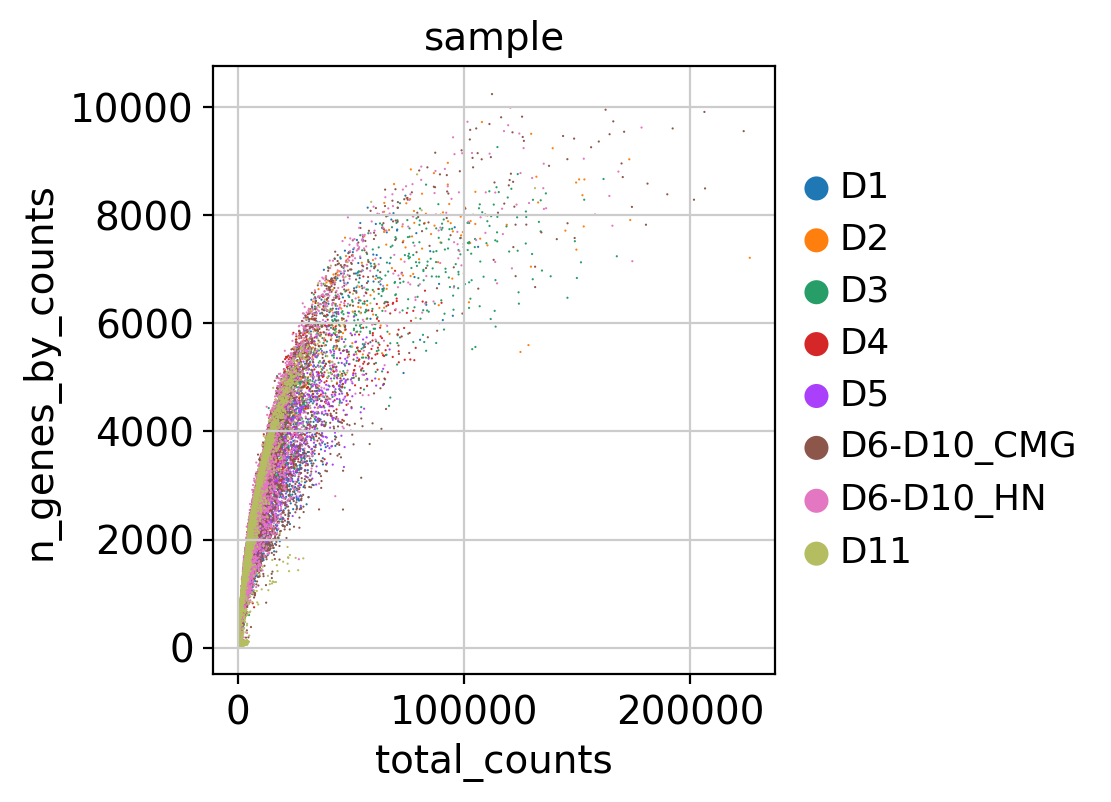

In [32]:
sc.pl.scatter(adata_qc_check, x='total_counts', y='n_genes_by_counts', color='sample')

## Filtering and doublet removal

Cells are filtered on gene count (>200, <6000), mitochondrial content (<20%), and 
genes detected in fewer than 5 cells are removed. Doublets are then flagged per-sample 
using Scrublet, since doublet rates are sample-specific.

In [33]:
filtered_adatas = {}
for name, ad in adatas.items():
    n_before = ad.n_obs
    ad = ad[ad.obs['n_genes_by_counts'] > 200, :]
    ad = ad[ad.obs['n_genes_by_counts'] < 6000, :]
    ad = ad[ad.obs['pct_counts_mt'] < 20, :]
    sc.pp.filter_genes(ad, min_cells=5)
    ad = ad.copy()

    sc.pp.scrublet(ad, batch_key=None)
    ad = ad[ad.obs['predicted_doublet'] == False].copy()

    filtered_adatas[name] = ad
    print(f"{name}: {n_before} -> {ad.n_obs} cells after QC + doublet removal")

/home/bioinfo3/miniconda3/envs/Seurat/lib/python3.14/site-packages/scanpy/preprocessing/_simple.py:280: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


D1: 4853 -> 4748 cells after QC + doublet removal


/home/bioinfo3/miniconda3/envs/Seurat/lib/python3.14/site-packages/scanpy/preprocessing/_simple.py:280: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


D2: 1399 -> 1258 cells after QC + doublet removal


/home/bioinfo3/miniconda3/envs/Seurat/lib/python3.14/site-packages/scanpy/preprocessing/_simple.py:280: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


...

D6-D10_CMG: 10961 -> 10303 cells after QC + doublet removal


/home/bioinfo3/miniconda3/envs/Seurat/lib/python3.14/site-packages/scanpy/preprocessing/_simple.py:280: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


D6-D10_HN: 9651 -> 9226 cells after QC + doublet removal


/home/bioinfo3/miniconda3/envs/Seurat/lib/python3.14/site-packages/scanpy/preprocessing/_simple.py:280: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


D11: 8334 -> 7402 cells after QC + doublet removal


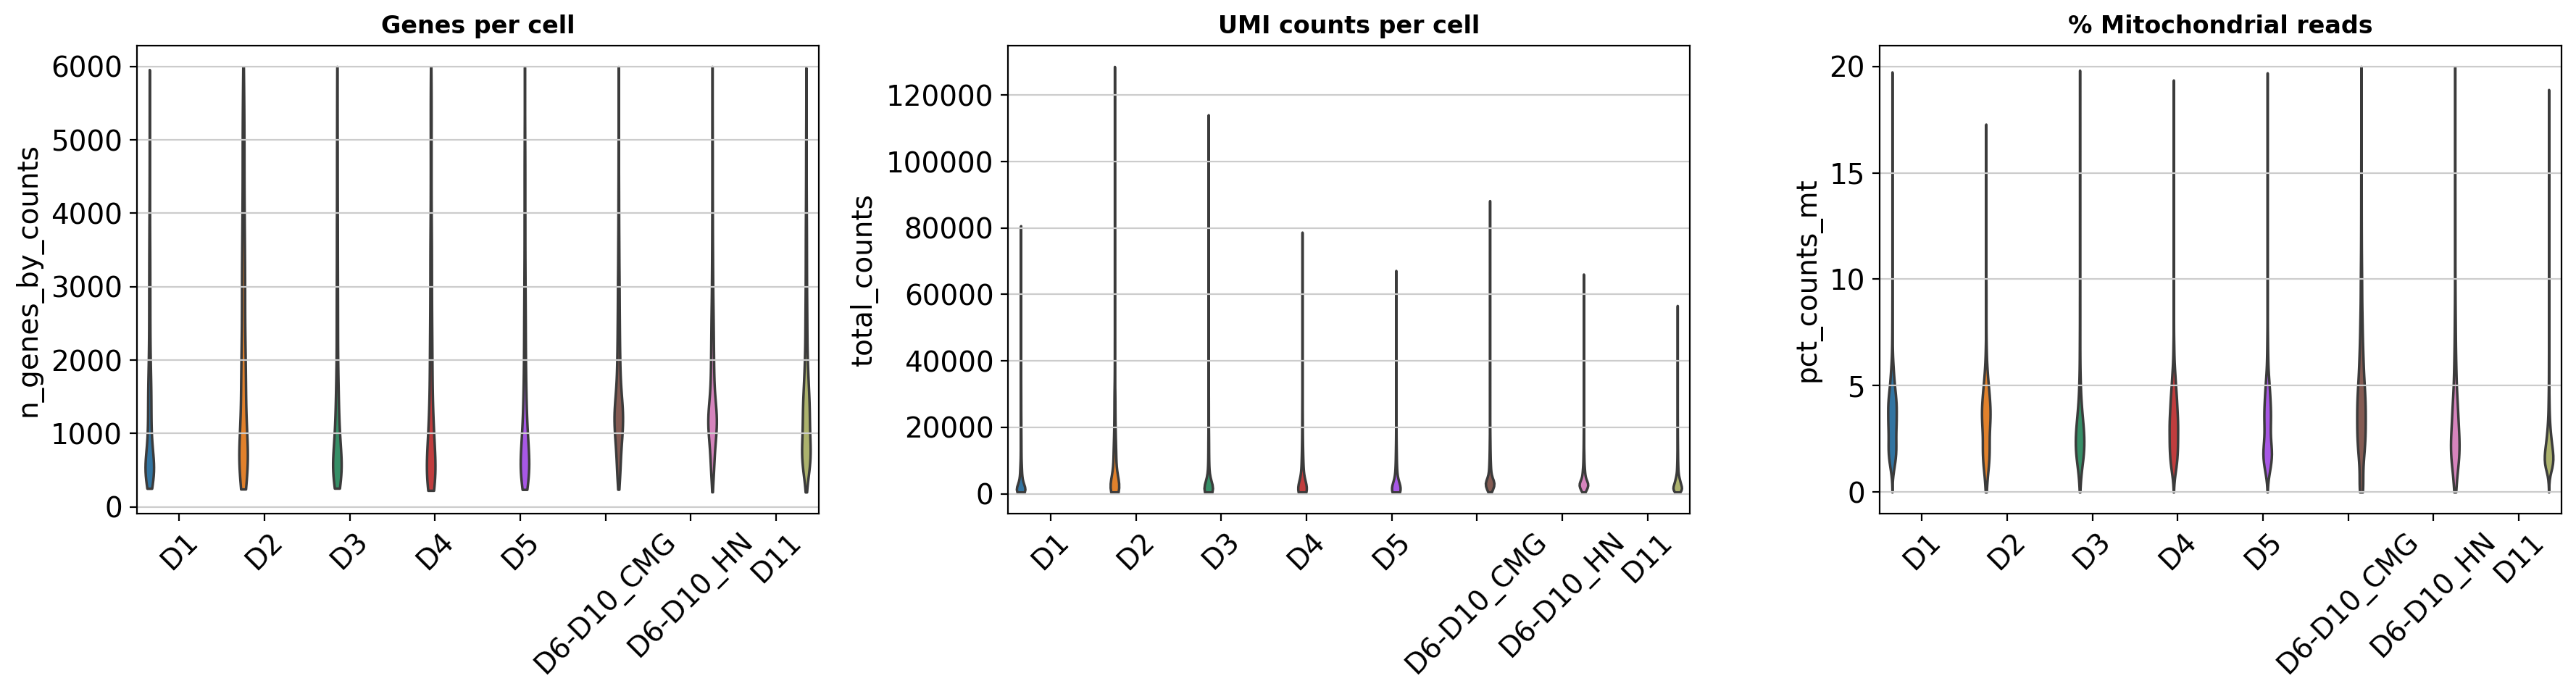

In [35]:
adata_post_filter = sc.concat(
    filtered_adatas,
    label='sample',
    index_unique='-'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(
    axes,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    ['Genes per cell', 'UMI counts per cell', '% Mitochondrial reads']
):
    sc.pl.violin(
        adata_post_filter,
        metric,
        groupby='sample',
        rotation=45,
        stripplot=False,
        ax=ax,
        show=False,
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.savefig('qc_violin_postfilter.png', dpi=300, bbox_inches='tight')
plt.show()

## Combine samples and save checkpoint

All samples are concatenated into a single AnnData object, retaining sample identity 
for downstream batch correction. Raw counts are preserved in a layer, and the data is 
normalized (CP10K) and log-transformed.

In [12]:
adata_combined = sc.concat(filtered_adatas, label='sample', join='outer', fill_value=0)
adata_combined.obs_names_make_unique()

adata_combined.layers['counts'] = adata_combined.X.copy()
sc.pp.normalize_total(adata_combined, target_sum=1e4)
sc.pp.log1p(adata_combined)

print(adata_combined)
adata_combined.write('checkpoints/adata_combined_normalized.h5ad')

/home/bioinfo3/miniconda3/envs/sc-tutorial/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 45858 × 22445
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'sample'
    uns: 'log1p'
    layers: 'counts'
